
# Initialization of data



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

coordinates_df = pd.read_csv('/content/drive/MyDrive/DL_Project_June/Datasets/coordinates.csv', header=None, index_col=False, sep=';')
# header= none: we don't have col names in the first raw
# index_col: we don't have a col for the index
print(coordinates_df.head(), coordinates_df.shape)



# Forces:
forces_df_raw = pd.read_csv('/content/drive/MyDrive/DL_Project_June/Datasets/forces.csv', header=None, index_col=False, sep=None, engine='python')
# sep = none means pandas will search to find the separator
forces_df = forces_df_raw[0].str.split('\t', expand=True)
forces_df = forces_df.apply(pd.to_numeric, errors='coerce')
print(forces_df.head(), forces_df.shape)

# velocity:
velocities_df_raw = pd.read_csv('/content/drive/MyDrive/DL_Project_June/Datasets/velocity.csv', header=None, index_col=False, sep=None, engine='python')
velocities_df = velocities_df_raw[0].str.split('\t', expand=True)
velocities_df = velocities_df.apply(pd.to_numeric, errors='coerce')
print(velocities_df.head(), velocities_df.shape)

     0        1        2        3        4        5        6        7    \
0  0.000  56.3980  51.9370  52.6880  56.3750  52.0050  52.6170  56.4260   
1  0.002  56.3992  51.9368  52.6877  56.3743  52.0037  52.6162  56.4267   
2  0.004  56.3999  51.9366  52.6871  56.3767  52.0046  52.6161  56.4285   
3  0.006  56.4001  51.9364  52.6861  56.3816  52.0073  52.6167  56.4315   
4  0.008  56.4001  51.9362  52.6848  56.3876  52.0109  52.6179  56.4350   

       8        9    ...      405      406      407      408      409  \
0  51.8530  52.6400  ...  52.1880  56.7460  52.0040  52.3850  56.7650   
1  51.8556  52.6344  ...  52.1872  56.7448  52.0025  52.3849  56.7651   
2  51.8579  52.6307  ...  52.1890  56.7434  52.0011  52.3842  56.7652   
3  51.8594  52.6288  ...  52.1930  56.7417  52.0001  52.3832  56.7652   
4  51.8597  52.6288  ...  52.1982  56.7402  51.9995  52.3824  56.7651   

       410      411      412      413      414  
0  51.9040  52.4540  56.7550  52.1200  52.4210  
1  51.9044  


1- Drop the first column (timesteps)

In [5]:
# 1- Drop the first column (timesteps)
coords = coordinates_df.iloc[:, 1:].values
vels   = velocities_df.iloc[:, 1:].values
forces = forces_df.iloc[:, 1:].values
print("\nAfter removing first column:")
print("Coordinates:", coords.shape)
print("Velocities :", vels.shape)
print("Forces     :", forces.shape)

# 2-  RESHAPE TO (timesteps, atoms, xyz)
NUM_ATOMS = 138

coords = coords.reshape(-1, NUM_ATOMS, 3)
vels   = vels.reshape(-1, NUM_ATOMS, 3)
forces = forces.reshape(-1, NUM_ATOMS, 3)

print("\nAfter reshape:")
print("Coordinates:", coords.shape)
print("Velocities :", vels.shape)
print("Forces     :", forces.shape)

#3- Concatenate Features to be [x,y,z,vx,vy,vz,fx,fy,fz]
import numpy as np
features = np.concatenate(
    [coords, vels, forces],
    axis=-1
)

print("\nCombined features shape:")
print(features.shape)

# 4- Scale Features
#FIT SCALAR ON TRAINING DATA ONLY
from sklearn.preprocessing import StandardScaler

N         = len(features)       # 50001

train_end = int(N * 0.70)       # 35000
val_end   = int(N * 0.85)       # 42500

# Fit scaler on training data ONLY — prevents leakage from future frames
train_data = features[:train_end].reshape(-1, 9)   # (35000*138, 9)

scaler = StandardScaler()
scaler.fit(train_data)

def scale_data(data):
    T = data.shape[0]
    data_scaled = scaler.transform(data.reshape(-1, 9))
    return data_scaled.reshape(T, 138, 9).astype('float32')

# features shape = (50001,138,9)

features_scaled = scale_data(features)

print('Scaling is done')
print("Train mean:", features_scaled[:train_end].mean())
print("Val mean:", features_scaled[train_end:val_end].mean())
print("Test mean:", features_scaled[val_end:].mean())

features_scaled[:train_end].reshape(-1, 9).mean(axis=0)



After removing first column:
Coordinates: (50001, 414)
Velocities : (50001, 414)
Forces     : (50001, 414)

After reshape:
Coordinates: (50001, 138, 3)
Velocities : (50001, 138, 3)
Forces     : (50001, 138, 3)

Combined features shape:
(50001, 138, 9)
Scaling is done
Train mean: -7.6196365e-08
Val mean: -0.96301705
Test mean: -1.4792347


array([-6.7091067e-05, -1.6351226e-04,  1.4109928e-04,  2.3492939e-08,
        6.1220732e-08, -1.9674330e-08, -2.8648485e-11, -5.6235072e-10,
        5.2429877e-10], dtype=float32)

# Atom level Transformer #1

We designed an** Atom-Level Transformer** that processes each atom individually but gives it access to its **10 nearest neighbors** on each side (20 neighbors total, plus the atom itself = 21 atoms). For each atom i at each timestep, the input includes all 9 features (x, y, z, vx, vy, vz, fx, fy, fz) for atoms i-10 through i+10. The model predicts the feature delta for atom i only

In [ ]:
import tensorflow as tf
import numpy as np

SPATIAL_WINDOW = 10      # neighbors on each side so 21 atoms total
T_WINDOW       = 10      # temporal window
ATOMS_IN       = 2 * SPATIAL_WINDOW + 1   # 21
F              = 9       # features per atom
BATCH_SIZE     = 64
N_ATOMS_SAMPLE = 20      # sample this many atoms per timestep
# instead of 138 atoms I will take 20 atoms per timestep

def make_atom_generator(features_arr, t_window, spatial_window,
                         batch_size, n_atoms_sample=20, shuffle=False):
    """
    For each atom a, extracts:
      X: (t_window, 21*9=189) — temporal window of spatial neighborhood
      Y: (9,)                  — next frame features for center atom
    """
    N, A, Feat = features_arr.shape   # (50001, 138, 9)
    S = spatial_window

    # Pad atoms axis for boundary atoms
    # like atom 0 doesn't have neighbors so I will add padding
    padded = np.pad(features_arr,
                    ((0, 0), (S, S), (0, 0)),
                    mode='edge').astype(np.float32)
    # padded shape: (50001, 158, 9)
    # 158 = 138 + 10 on theright edge and 10 on the left edge
    # 158 = 138+10+10

    def generator():
        timesteps = np.arange(t_window, N - 1)
        # if t_window = 10 so the first usable timestep is t=10 because I want the last 10 frames
        if shuffle:
            np.random.shuffle(timesteps)

        for t in timesteps:
            # Sample random atoms instead of all 138
            # I will take 20 atoms from the 138 atoms in each timestep
            atoms = np.random.choice(A, size=n_atoms_sample, replace=False)

            for a in atoms:
                # Spatial neighborhood across temporal window
                # padded[t-T:t, a:a+21, :] → shape (T, 21, 9)
                # this will take the last 10 timesteps, 21 atoms , each atom 9 features
                # the shape is (10, 21, 9)
                neighborhood = padded[t - t_window:t, a:a + 2*S + 1, :]
                # I will do reshape to (10, 189) cuz: 21*9 =189
                x = neighborhood.reshape(t_window, -1)   # (T, 189)


                # the model will predict the central atom in the next timestep
                y = features_arr[t + 1, a, :]            # (9,)
                yield x.astype(np.float32), y.astype(np.float32)

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(T_WINDOW, ATOMS_IN * F), dtype=tf.float32), # input TensorSpec(shape=(10, 189))
            tf.TensorSpec(shape=(F,),                      dtype=tf.float32) # output TensorSpec(shape=(9,))
        )
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=5000)

    ds = ds.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)
    # we colleced the samples ,make the dataset infiniy thats why we need steps per epochs
    # and we prepared the batches in advance to spped up the training
    return ds


# Splits
train_feat = features_scaled[:35000]   # (35000, 138, 9)
val_feat   = features_scaled[35000:42500]
test_feat  = features_scaled[42500:]

train_atom_ds = make_atom_generator(train_feat, T_WINDOW, SPATIAL_WINDOW,
                                     BATCH_SIZE, N_ATOMS_SAMPLE, shuffle=True)
val_atom_ds   = make_atom_generator(val_feat,   T_WINDOW, SPATIAL_WINDOW,
                                     BATCH_SIZE, N_ATOMS_SAMPLE)
test_atom_ds  = make_atom_generator(test_feat,  T_WINDOW, SPATIAL_WINDOW,
                                     BATCH_SIZE, N_ATOMS_SAMPLE)

# Steps per epoch
n_train_steps = (35000 - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE
# for each timestep we generate 20samples  => no of samples = (35000-10)*20 the divide by the batch size
n_val_steps   = (7500  - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE
n_test_steps  = (7501  - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE

# Shape check
for X_b, Y_b in train_atom_ds.take(1):
    print('X batch:', X_b.shape)   # (64, 10, 189)
    print('Y batch:', Y_b.shape)   # (64, 9)
print(f'Steps/epoch train: {n_train_steps}')
print(f'Steps/epoch val  : {n_val_steps}')

X batch: (64, 10, 189)
Y batch: (64, 9)
Steps/epoch train: 10934
Steps/epoch val  : 2340


In [6]:
import tensorflow as tf
import numpy as np
def positional_encoding(length, depth):
    depth     = depth / 2
    positions = np.arange(length)[:, np.newaxis]
    depths    = np.arange(depth)[np.newaxis, :] / depth
    angle_rates  = 1 / (10000 ** depths)
    angle_rads   = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)


class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.projection   = tf.keras.layers.Dense(d_model)
        self.pos_encoding = positional_encoding(length=2048, depth=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        x  = self.projection(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x  = x + self.pos_encoding[tf.newaxis, :seq_len, :]
        return x


class BaseAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha       = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add       = tf.keras.layers.Add()


class CrossAttention(BaseAttention):
    def call(self, x, context):
        attn_output, attn_scores = self.mha(
            query=x, key=context, value=context, return_attention_scores=True)
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x


class GlobalSelfAttention(BaseAttention):
    def call(self, x):
        attn_output = self.mha(query=x, value=x, key=x)
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x


class CausalSelfAttention(BaseAttention):
    def call(self, x):
        attn_output = self.mha(query=x, value=x, key=x, use_causal_mask=True)
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x


class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(dropout_rate)])
        self.add        = tf.keras.layers.Add()
        self.layer_norm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        x = self.add([x, self.seq(x)])
        x = self.layer_norm(x)
        return x


class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = GlobalSelfAttention(
            num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff)

    def call(self, x):
        x = self.self_attention(x)
        x = self.ffn(x)
        return x


class Encoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.d_model       = d_model
        self.num_layers    = num_layers
        self.pos_embedding = PositionalEmbedding(d_model=d_model)
        self.enc_layers    = [
            EncoderLayer(d_model=d_model, num_heads=num_heads,
                         dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for layer in self.enc_layers:
            x = layer(x)
        return x

class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,
               *,
               d_model,
               num_heads,
               dff,
               dropout_rate=0.1):
    super(DecoderLayer, self).__init__()

    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)

  def call(self, x, context):
    x = self.causal_self_attention(x=x)
    x = self.cross_attention(x=x, context=context)

    # Cache the last attention scores for plotting later
    self.last_attn_scores = self.cross_attention.last_attn_scores

    x = self.ffn(x)  # Shape `(batch_size, seq_len, d_model)`.
    return x
class Decoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads, dff,
               dropout_rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(
                                             d_model=d_model)
    self.dropout = tf.keras.layers.Dropout(dropout_rate)
    self.dec_layers = [
        DecoderLayer(d_model=d_model, num_heads=num_heads,
                     dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    self.last_attn_scores = None

  def call(self, x, context):
    # `x` is token-IDs shape (batch, target_seq_len)
    x = self.pos_embedding(x)  # (batch_size, target_seq_len, d_model)

    x = self.dropout(x)

    for i in range(self.num_layers):
      x  = self.dec_layers[i](x, context)

    self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # The shape of x is (batch_size, target_seq_len, d_model).
    return x
# CustomSchedule — kept for reference, not used for training
# (causes severe overfitting on this small regression task)
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, dtype=tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)


print('All Transformer classes defined.')

All Transformer classes defined.


In [ ]:
class AtomTransformer(tf.keras.Model):
    """
    Predicts next-frame 9 features for one atom,
    given a temporal window of its 21-atom spatial neighborhood.

    Input : (B, T, 189)  — T frames × 21 atoms × 9 features (flattened)
    Output: (B, 9)        — next frame x,y,z,vx,vy,vz,fx,fy,fz for center atom
    """
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 output_dim=9, dropout_rate=0.1):
        super().__init__()
        self.encoder = Encoder(num_layers=num_layers, d_model=d_model,
                                    num_heads=num_heads, dff=dff,
                                    dropout_rate=dropout_rate)

        self.decoder = Decoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           dropout_rate=dropout_rate)

        self.output_layer = tf.keras.layers.Dense(output_dim)

    def call(self, x, training=False):
        x = self.encoder(x, training=training)   # (B, T, d_model)
        x = x[:, -1, :]                          # (B, d_model)
        return self.output_layer(x)              # (B, 9)


    def call(self, inputs):
      # To use a Keras model with `.fit` you must pass all your inputs in the
      # first argument.
      context, x  = inputs

      context = self.encoder(context)  # (batch_size, context_len, d_model)

      x = self.decoder(x, context)  # (batch_size, target_len, d_model)

      # Final linear layer output.
      logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size)

      try:
        # Drop the keras mask, so it doesn't scale the losses/metrics.
        # b/250038731
        del logits._keras_mask
      except AttributeError:
        pass

      # Return the final output and the attention weights.
      return logits

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))


# Build and compile

atom_model = AtomTransformer(
    num_layers=1, d_model=32, num_heads=2, dff=64,
    output_dim=9, dropout_rate=0.1)

# Warm-up
for X_b, _ in train_atom_ds.take(1):
    atom_model(X_b, training=False)

atom_model.compile(
    loss=mse_loss,
    optimizer=tf.keras.optimizers.Adam(1e-4),
    metrics=[mae_metric])

print(f'Parameters: {atom_model.count_params():,}')

Parameters: 19,113


In [ ]:
atom_history = atom_model.fit(
    train_atom_ds,
    validation_data=val_atom_ds,
    epochs=30,
    steps_per_epoch=n_train_steps,
    validation_steps=n_val_steps,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1)],
    verbose=1)

plot_loss(atom_history)

Epoch 1/30
10934/10934 ━━━━━━━━━━━━━━━━━━━━ 316s 27ms/step - loss: 0.4072 - mae_metric: 0.4278 - val_loss: 0.4211 - val_mae_metric: 0.4981
Epoch 2/30
10934/10934 ━━━━━━━━━━━━━━━━━━━━ 302s 27ms/step - loss: 0.2078 - mae_metric: 0.3058 - val_loss: 0.3112 - val_mae_metric: 0.4243
Epoch 3/30
10934/10934 ━━━━━━━━━━━━━━━━━━━━ 297s 27ms/step - loss: 0.1920 - mae_metric: 0.2909 - val_loss: 0.2830 - val_mae_metric: 0.4034
Epoch 4/30
10934/10934 ━━━━━━━━━━━━━━━━━━━━ 297s 27ms/step - loss: 0.1833 - mae_metric: 0.2831 - val_loss: 0.2495 - val_mae_metric: 0.3746
Epoch 5/30
10934/10934 ━━━━━━━━━━━━━━━━━━━━ 300s 27ms/step - loss: 0.1760 - mae_metric: 0.2766 - val_loss: 0.2439 - val_mae_metric: 0.3704
Epoch 6/30
10934/10934 ━━━━━━━━━━━━━━━━━━━━ 301s 28ms/step - loss: 0.1692 - mae_metric: 0.2706 - val_loss: 0.2186 - val_mae_metric: 0.3477
Epoch 7/30
10934/10934 ━━━━━━━━━━━━━━━━━━━━ 302s 28ms/step - loss: 0.1603 - mae_metric: 0.2635 - val_loss: 0.1875 - val_mae_metric: 0.3206
Epoch 8/30
10934/10934 ━━━━

It's working and learning well
val_loss is steadily decreasing from  0.421 -> 0.127. But each epoch takes 5 minutes and while I'm at epoch 21 of 30 the GPU resources is finished on Colab
So 1-Reduce atoms sampled per timestep 5   #  it was 20
2- Reduce temporal window: 5   # it was 10
3- Smaller model:


In [7]:
# CELL 1 — Dataset with reduced parameters
import tensorflow as tf
import numpy as np

SPATIAL_WINDOW = 10
T_WINDOW       = 5       # was 10 → faster
ATOMS_IN       = 2 * SPATIAL_WINDOW + 1   # 21
F              = 9
BATCH_SIZE     = 64
N_ATOMS_SAMPLE = 5       # was 20 → 4x fewer steps

def make_atom_generator(features_arr, t_window, spatial_window,
                         batch_size, n_atoms_sample=5, shuffle=False):
    N, A, Feat = features_arr.shape
    S = spatial_window

    padded = np.pad(features_arr,
                    ((0, 0), (S, S), (0, 0)),
                    mode='edge').astype(np.float32)

    def generator():
        timesteps = np.arange(t_window, N - 1)
        if shuffle:
            np.random.shuffle(timesteps)

        for t in timesteps:
            atoms = np.random.choice(A, size=n_atoms_sample, replace=False)
            for a in atoms:
                neighborhood = padded[t - t_window:t, a:a + 2*S + 1, :]
                x = neighborhood.reshape(t_window, -1).astype(np.float32)
                y = features_arr[t + 1, a, :].astype(np.float32)
                yield x, y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(T_WINDOW, ATOMS_IN * F), dtype=tf.float32),
            tf.TensorSpec(shape=(F,),                      dtype=tf.float32)
        )
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)

    ds = ds.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)
    return ds


train_feat = features_scaled[:35000]
val_feat   = features_scaled[35000:42500]
test_feat  = features_scaled[42500:]

train_atom_ds = make_atom_generator(train_feat, T_WINDOW, SPATIAL_WINDOW,
                                     BATCH_SIZE, N_ATOMS_SAMPLE, shuffle=True)
val_atom_ds   = make_atom_generator(val_feat,   T_WINDOW, SPATIAL_WINDOW,
                                     BATCH_SIZE, N_ATOMS_SAMPLE)
test_atom_ds  = make_atom_generator(test_feat,  T_WINDOW, SPATIAL_WINDOW,
                                     BATCH_SIZE, N_ATOMS_SAMPLE)

n_train_steps = (35000 - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE
n_val_steps   = (7500  - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE
n_test_steps  = (7501  - T_WINDOW) * N_ATOMS_SAMPLE // BATCH_SIZE

for X_b, Y_b in train_atom_ds.take(1):
    print('X batch:', X_b.shape)   # (64, 5, 189)
    print('Y batch:', Y_b.shape)   # (64, 9)
print(f'Steps/epoch train: {n_train_steps}')
print(f'Steps/epoch val  : {n_val_steps}')

X batch: (64, 5, 189)
Y batch: (64, 9)
Steps/epoch train: 2733
Steps/epoch val  : 585


In [ ]:
# CELL 2 — Smaller AtomTransformer model
class AtomTransformer(tf.keras.Model):
    """
    Predicts next-frame 9 features for one atom,
    given temporal window of its 21-atom spatial neighborhood.
    Input : (B, T, 189)
    Output: (B, 9)
    """
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 output_dim=9, dropout_rate=0.1):
        super().__init__()
        self.encoder      = Encoder(num_layers=num_layers, d_model=d_model,
                                    num_heads=num_heads, dff=dff,
                                    dropout_rate=dropout_rate)
        self.output_layer = tf.keras.layers.Dense(output_dim)

    def call(self, x, training=False):
        x = self.encoder(x, training=training)   # (B, T, d_model)
        x = x[:, -1, :]                          # (B, d_model)
        return self.output_layer(x)              # (B, 9)


atom_model = AtomTransformer(
    num_layers=1, d_model=16, num_heads=2, dff=32,   # smaller model
    output_dim=9, dropout_rate=0.1)

for X_b, _ in train_atom_ds.take(1):
    atom_model(X_b, training=False)
def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))
atom_model.compile(
    loss=mse_loss,
    optimizer=tf.keras.optimizers.Adam(1e-4),
    metrics=[mae_metric])

print(f'Parameters: {atom_model.count_params():,}')

NameError: name 'Encoder' is not defined

In [ ]:
# CELL 3 — Training
atom_history = atom_model.fit(
    train_atom_ds,
    validation_data=val_atom_ds,
    epochs=30,
    steps_per_epoch=n_train_steps,
    validation_steps=n_val_steps,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1)],
    verbose=1)

# Save immediately
atom_model.save_weights('atom_transformer.weights.h5')
print('Saved: atom_transformer.weights.h5')

# Plot
plot_loss(atom_history)
plt.savefig('atom_transformer.jpg', dpi=300, bbox_inches='tight')
plt.show()

# Results
best_val_mse = min(atom_history.history['val_loss'])
best_val_mae = min(atom_history.history['val_mae_metric'])

test_mse, test_mae = atom_model.evaluate(
    test_atom_ds, steps=n_test_steps, verbose=0)

print(f'val  MSE={best_val_mse:.6f} | val  MAE={best_val_mae:.6f}')
print(f'test MSE={test_mse:.6f}     | test MAE={test_mae:.6f}')

Epoch 1/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - loss: 0.7985 - mae_metric: 0.6259 - val_loss: 1.3587 - val_mae_metric: 0.9162
Epoch 2/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - loss: 0.4446 - mae_metric: 0.4647 - val_loss: 0.7756 - val_mae_metric: 0.6814
Epoch 3/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 75s 27ms/step - loss: 0.2985 - mae_metric: 0.3830 - val_loss: 0.6324 - val_mae_metric: 0.6133
Epoch 4/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 74s 27ms/step - loss: 0.2565 - mae_metric: 0.3489 - val_loss: 0.4825 - val_mae_metric: 0.5321
Epoch 5/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 74s 27ms/step - loss: 0.2366 - mae_metric: 0.3303 - val_loss: 0.4197 - val_mae_metric: 0.4960
Epoch 6/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - loss: 0.2267 - mae_metric: 0.3206 - val_loss: 0.3789 - val_mae_metric: 0.4694
Epoch 7/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 76s 28ms/step - loss: 0.2192 - mae_metric: 0.3141 - val_loss: 0.3793 - val_mae_metric: 0.4734
Epoch 8/30
2733/2733 ━━━━━━━━━━━━━━━━━━━━ 75s 28

NameError: name 'plot_loss' is not defined

In [ ]:
import matplotlib.pyplot as plt
def plot_loss(history):
    history_dict    = history.history
    loss_values     = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    epochs = range(1, len(loss_values) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss_values,     'b', label='Training loss')
    plt.plot(epochs, val_loss_values, 'r',  label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper center')

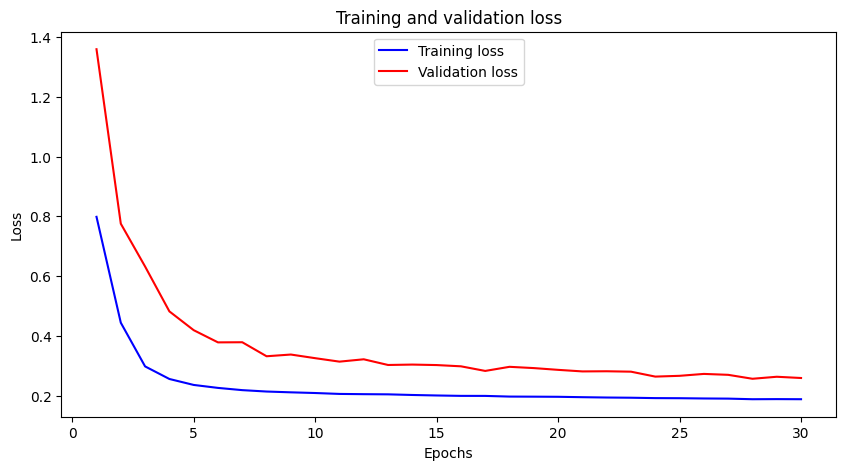

In [ ]:
# Plot
plot_loss(atom_history)
plt.savefig('atom_transformer.jpg', dpi=300, bbox_inches='tight')
plt.show()